# Lungelo Ndumiso Ntombela
# Data Science
# TASK 1 · Iris Flower Classification

## Objective
Train classification models to identify **Setosa, Versicolor, or Virginica** from physical flower measurements.


In [ ]:
#libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.feature_selection import f_classif
RANDOM_STATE = 42

In [26]:
iris = load_iris()

iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)
iris_df["species"] = pd.Categorical.from_codes(
    iris.target, categories=iris.target_names
)

display(iris_df.head())

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## 1.1 Exploratory Data Analysis


In [27]:
print("Dataset shape:", iris_df.shape)
print("\nData types:")
print(iris_df.dtypes)

print("\nMissing values:")
display(iris_df.isnull().sum().to_frame("Missing Values"))

print("\nTotal missing values:", iris_df.isnull().sum().sum())
print("Duplicate rows:", iris_df.duplicated().sum())

print("\nDescriptive statistics:")
display(iris_df.describe().round(2))

print("\nClass distribution:")
display(iris_df["species"].value_counts())

Dataset shape: (150, 5)

Data types:
sepal length (cm)     float64
sepal width (cm)      float64
petal length (cm)     float64
petal width (cm)      float64
species              category
dtype: object

Missing values:


,Missing Values
sepal length (cm),0
sepal width (cm),0
petal length (cm),0
petal width (cm),0
species,0



Total missing values: 0
Duplicate rows: 1

Descriptive statistics:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20
std,0.83,0.44,1.77,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50



Class distribution:


species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

In [28]:
iris_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   sepal length (cm)  150 non-null    float64 
 1   sepal width (cm)   150 non-null    float64 
 2   petal length (cm)  150 non-null    float64 
 3   petal width (cm)   150 non-null    float64 
 4   species            150 non-null    category
dtypes: category(1), float64(4)
memory usage: 5.1 KB


## 1.2 Pairplot — Feature Distributions by Species


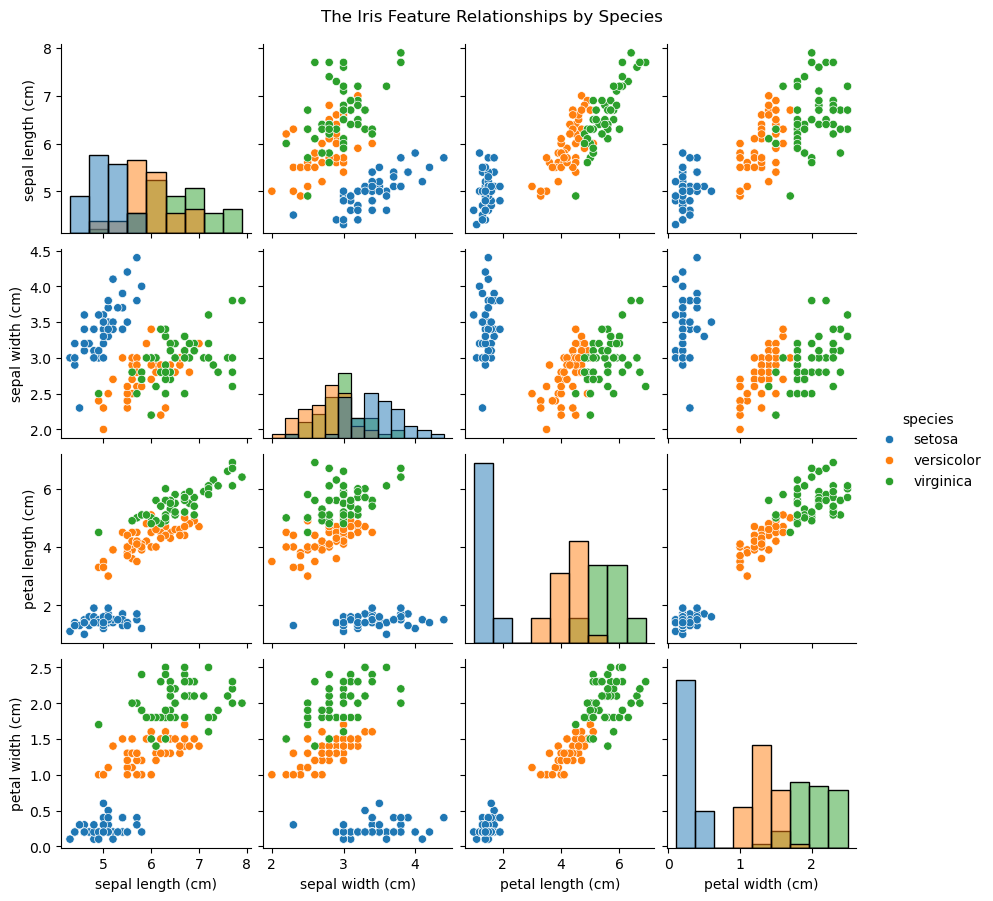

In [29]:
sns.pairplot(
    iris_df,
    hue="species",
    diag_kind="hist",
    height=2.2
)
plt.suptitle("The Iris Feature Relationships by Species", y = 1.02)
plt.show()

## 1.3 The Box Plots for Each Feature


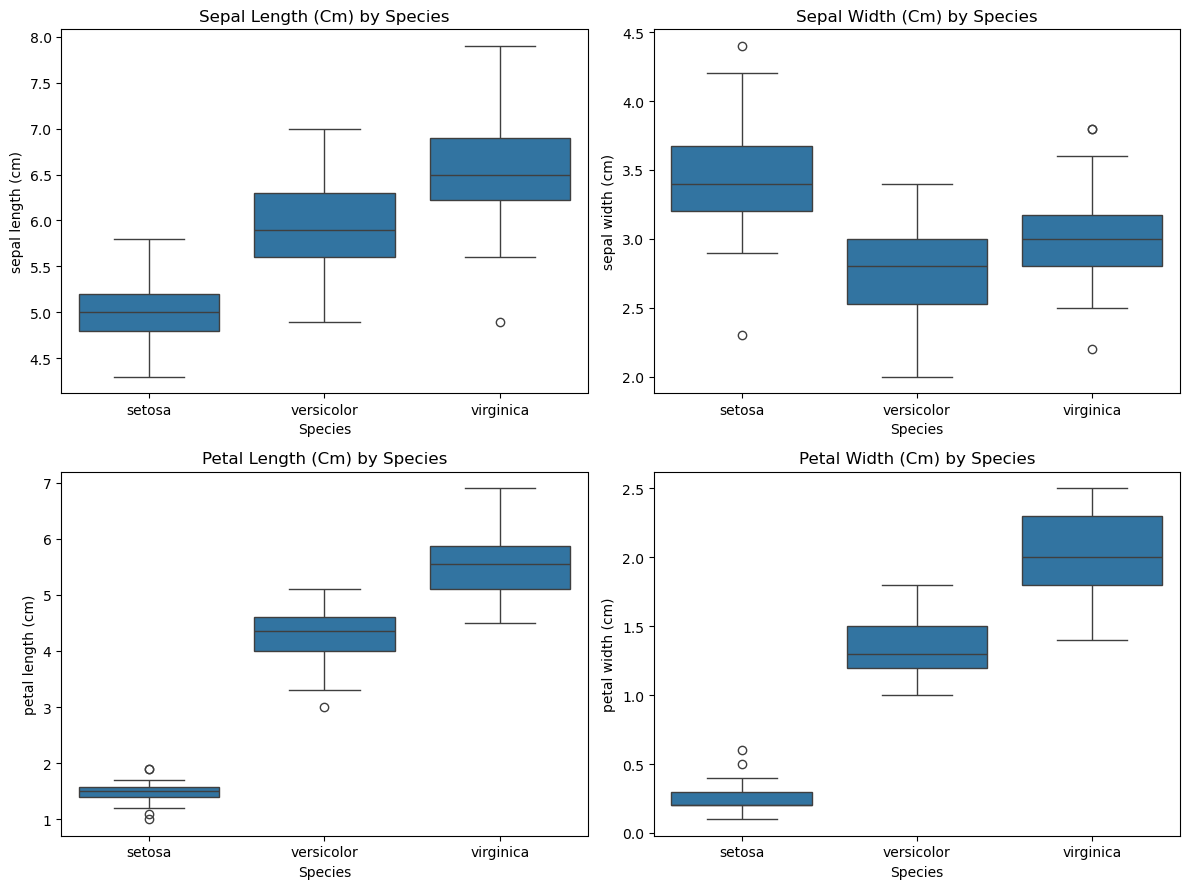

In [30]:
features = iris.feature_names

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, feature in zip(axes.flatten(), features):
    sns.boxplot(data=iris_df, x="species", y=feature, ax=ax)
    ax.set_title(f"{feature.title()} by Species")
    ax.set_xlabel("Species")
    ax.set_ylabel(feature)

plt.tight_layout()
plt.show()

## 1.4 Feature Selection




In [31]:
X_iris = iris_df[features]
y_iris = iris_df["species"]

f_scores, p_values = f_classif(X_iris, y_iris)

iris_feature_scores = pd.DataFrame({
    "Feature": features,
    "ANOVA_F_Score": f_scores,
    "p_value": p_values
}).sort_values("ANOVA_F_Score", ascending=False)

display(iris_feature_scores.round(6))
print(
    "Most discriminative features:",
    ", ".join(iris_feature_scores["Feature"].head(2))
)

,Feature,ANOVA_F_Score,p_value
2,petal length (cm),1180.161182,0.0
3,petal width (cm),960.007147,0.0
0,sepal length (cm),119.264502,0.0
1,sepal width (cm),49.160040,0.0


Most discriminative features: petal length (cm), petal width (cm)


## 1.5 Train/Test Split of the data


In [32]:
X_train_iris, X_test_iris, y_train_iris, y_test_iris = train_test_split(
    X_iris,
    y_iris,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_iris
)

print("Training samples:", len(X_train_iris))
print("Testing samples:", len(X_test_iris))

Training samples: 120
Testing samples: 30


## 1.6 Training of the Two Classification Models


In [33]:
logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

rf_classifier = RandomForestClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE
)

logistic_model.fit(X_train_iris, y_train_iris)
rf_classifier.fit(X_train_iris, y_train_iris)

logistic_pred = logistic_model.predict(X_test_iris)
rf_pred = rf_classifier.predict(X_test_iris)

print("Both classifiers trained successfully.")

Both classifiers trained successfully.


## 1.7 Model Evaluation



Logistic Regression
Accuracy: 0.9333

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



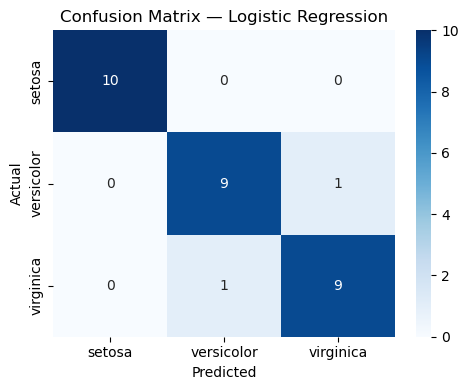


Random Forest
Accuracy: 0.9000

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



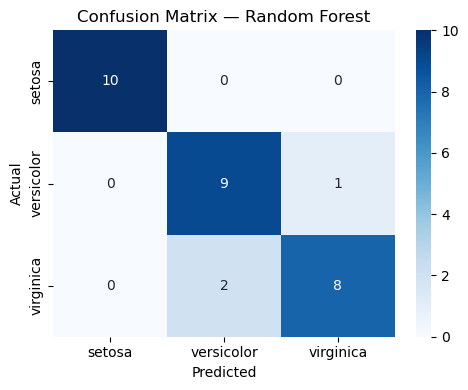


              Model  Accuracy
Logistic Regression  0.933333
      Random Forest  0.900000


In [34]:
# Evaluation on both models
results = []
models = [
    ("Logistic Regression", logistic_pred),
    ("Random Forest", rf_pred)
]

for name, predictions in models:
    acc = accuracy_score(y_test_iris, predictions)
    results.append({"Model": name, "Accuracy": acc})
    
    print(f"\n{name}")
    print(f"Accuracy: {acc:.4f}\n")
    print(classification_report(y_test_iris, predictions))
    
# Plotting of the confusion matrix
    cm = confusion_matrix(y_test_iris, predictions, labels=iris.target_names)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=iris.target_names, yticklabels=iris.target_names)
    plt.title(f"Confusion Matrix — {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()


results_df = pd.DataFrame(results).sort_values("Accuracy", ascending=False)
print("\n" + "="*50)
print(results_df.to_string(index=False))

## 1.8 Best Model


In [35]:
# Find the best model
best_model = results_df.iloc[0]

print(f"Best model: {best_model['Model']} ({best_model['Accuracy']:.2%} accuracy)")

Best model: Logistic Regression (93.33% accuracy)
